# 04p1: NDMM PBMC data doublet removed stats
### By [Mansi Singh](mansi.singh@alleninstitute.org), Comp Bio, Allen Institute for Immunology
**Aim:** Quantify and visualize the impact of doublet removal on cell-type composition at L3 resolution. Compare cell counts before and after doublet filtering and report per-cell-type removal rates.


## 1 Setup

In [ ]:
import pandas as pd               # DataFrames and tabular operations
import numpy as np                # Numerical computation
import matplotlib.pyplot as plt   # Static plotting
import seaborn as sns             # Statistical visualization
import os                         # File system utilities
import warnings

warnings.filterwarnings('ignore')

In [ ]:
# Load metadata: after manual doublet annotation and raw (pre-QC)
after_doublets = pd.read_csv("../../../data/rna/NDMM_pbmc_193samples_doublet_metadata_all_types.csv.gz")
before_doublets = pd.read_csv("../../../data/rna/ndmm-pbmc-csvs_pkls/2025-06-20-ndmm-pbmc-raw-all-metadata.csv")

In [ ]:
# Keep only cells marked as non-doublets ("no" = not a doublet)
after_doublets_no = after_doublets[after_doublets['doublets_manual'] == 'no']

In [ ]:
print(f"Cells after doublet removal: {after_doublets_no.shape[0]:,}")
print(f"Cells before QC (raw): {before_doublets.shape[0]:,}")

(2578117, 103)

In [ ]:
# Spot-check a rare cell type (BaEoMaP) to verify it appears in raw data
beom = before_doublets[before_doublets['tidy.aifi_l3'] == 'BaEoMaP cell']
print(f"BaEoMaP cells in raw data: {beom.shape[0]:,}")

,barcodes,barcodes.1,batch_id,cell_name,cell_uuid,chip_id,hto_barcode,hto_category,n_genes,n_mito_umis,...,manual.cyto.high_risk,manual.cyto.karyotype,manual.cyto.t11_14,manual.cyto.t14_16,manual.cyto.t14_20,manual.cyto.t4_14,manual.cyto.karyotype.1,tidy.aifi_l2,tidy.aifi_l1,tidy.aifi_l3
860,17767138cf5711eb92edee87f7fe9c5f,17767138cf5711eb92edee87f7fe9c5f,B017,emanatory_ghostlike_annelida,17767138cf5711eb92edee87f7fe9c5f,B017-P1C1,TGTCTTTCCTGCCAG,singlet,2469,381,...,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Progenitor cell,Other,BaEoMaP cell
2966,4ad5f6f2cf6111eb8484820f2a088f4f,4ad5f6f2cf6111eb8484820f2a088f4f,B017,privatized_blowzy_flatfish,4ad5f6f2cf6111eb8484820f2a088f4f,B017-P1C1,TGTCTTTCCTGCCAG,singlet,3256,465,...,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Progenitor cell,Other,BaEoMaP cell
4117,a5eec518cf1211ebbe2fa20e2f2ffd5c,a5eec518cf1211ebbe2fa20e2f2ffd5c,B017,batiste_ununhexium_buzzard,a5eec518cf1211ebbe2fa20e2f2ffd5c,B017-P1C1,TGTCTTTCCTGCCAG,singlet,1481,52,...,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Progenitor cell,Other,BaEoMaP cell
10343,9bd453c6cf6311eb804f2ea8a5deee0f,9bd453c6cf6311eb804f2ea8a5deee0f,B017,written_moonlit_drafthorse,9bd453c6cf6311eb804f2ea8a5deee0f,B017-P1C1,TGTCTTTCCTGCCAG,singlet,3557,84,...,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Progenitor cell,Other,BaEoMaP cell
15173,a8acf4dacf5f11ebbb4b469acf5ea95d,a8acf4dacf5f11ebbb4b469acf5ea95d,B017,uninvolved_sluggish_hartebeest,a8acf4dacf5f11ebbb4b469acf5ea95d,B017-P1C2,TGTCTTTCCTGCCAG,singlet,4486,464,...,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Not Tested,Progenitor cell,Other,BaEoMaP cell


## 2 Compute Per-Cell-Type Doublet Removal Stats

In [ ]:
# Cell counts per L3 cell type BEFORE doublet removal
counts_df_before = before_doublets.groupby('tidy.aifi_l3').size().reset_index(name='count_before')
print(counts_df_before)

                      tidy.aifi_l3  count_before
0                             ASDC           678
1          Activated memory B cell          1231
2                 Adaptive NK cell         62887
3                     BaEoMaP cell           183
4               C1Q+ CD16 monocyte         12561
..                             ...           ...
66          SOX4+ naive CD8 T cell           314
67             Transitional B cell         31804
68  Type 2 polarized memory B cell           718
69                            cDC1          2088
70                             pDC          8012

[71 rows x 2 columns]


In [ ]:
# Cell counts per L3 cell type AFTER doublet removal
counts_df_after = after_doublets_no.groupby('tidy.aifi_l3').size().reset_index(name='count_after')
print(counts_df_after)

                      tidy.aifi_l3  count_after
0                             ASDC          565
1          Activated memory B cell          761
2                 Adaptive NK cell        53160
3                     BaEoMaP cell          170
4               C1Q+ CD16 monocyte        10538
..                             ...          ...
67          SOX4+ naive CD8 T cell          237
68             Transitional B cell        28092
69  Type 2 polarized memory B cell          625
70                            cDC1         1600
71                             pDC         6520

[72 rows x 2 columns]


In [ ]:
# Left-join to keep all cell types (some may have zero after filtering)
df = pd.merge(counts_df_before, counts_df_after, how="left", on='tidy.aifi_l3')

In [ ]:
# Compute absolute and percentage differences
df['number_filtered'] = df['count_before'] - df['count_after']
df['percentage_filtered'] = (df['number_filtered'] / df['count_before']) * 100

## 3 Visualize Doublet Removal Impact

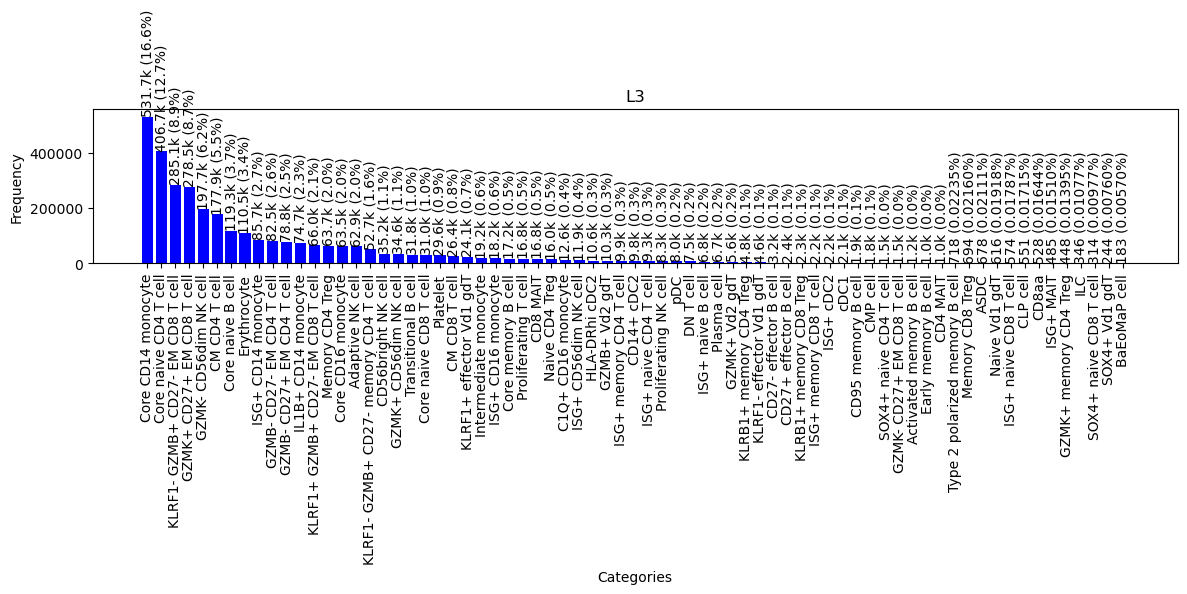

In [115]:
# Percentage of cell counts BEFORE any doublet removal
frequency_count_sorted = df.sort_values('count_before',ascending=False)

frequency_count_sorted.index=frequency_count_sorted['tidy.aifi_l3']
frequency_count_sorted=frequency_count_sorted['count_before']

plt.figure(figsize=(14, 2))  
total_frequency = sum(frequency_count_sorted)

bars = plt.bar(list(frequency_count_sorted.keys()), list(frequency_count_sorted.values), color='blue')

for bar in bars:
    height = bar.get_height()  
    percentage = (height / total_frequency) * 100  
    
    # Formatting the label with 'k' for thousands
    if height >= 1000:
        label = f"{height/1000:.1f}k ({percentage:.1f}%)"
    else:
        label = f"{int(height)} ({percentage:.5f}%)"

    plt.text(bar.get_x() + bar.get_width() / 2, height, label, 
             va='bottom', ha='center', rotation='vertical')  

plt.xlabel('Categories')
plt.ylabel('Frequency')
plt.title('L3')
plt.xticks(rotation='vertical')  

plt.show()



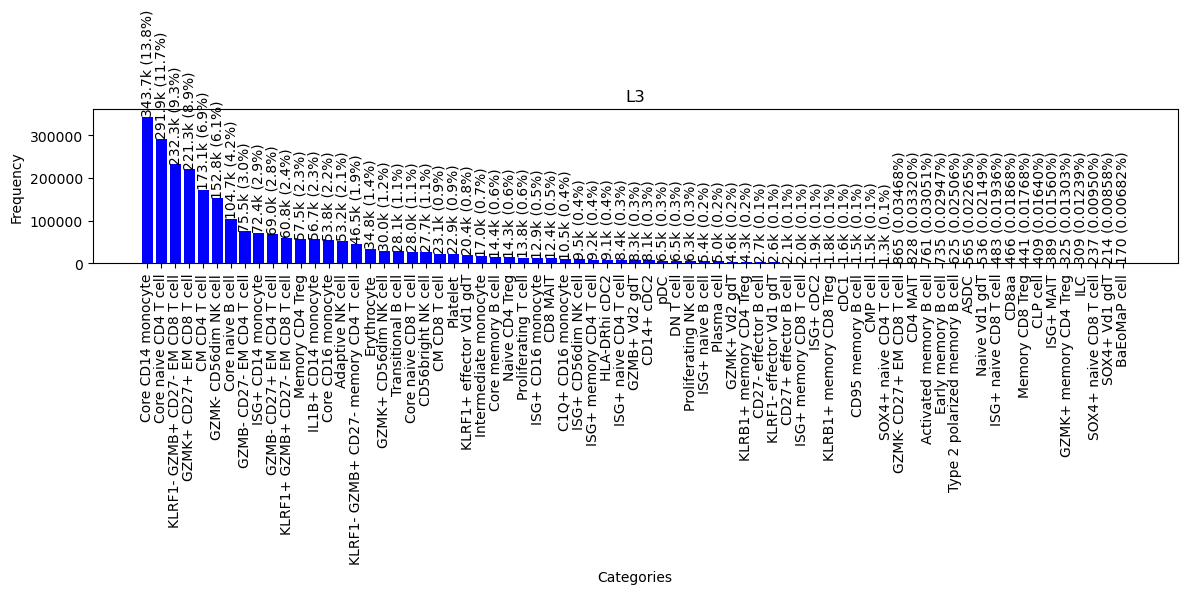

In [119]:
# Percentage of cell counts AFTER doublet removal
frequency_count_sorted = df.sort_values('count_after',ascending=False)

frequency_count_sorted.index=frequency_count_sorted['tidy.aifi_l3']
frequency_count_sorted=frequency_count_sorted['count_after']

plt.figure(figsize=(14, 2)) 
total_frequency = sum(frequency_count_sorted)

bars = plt.bar(list(frequency_count_sorted.keys()), list(frequency_count_sorted.values), color='blue')

for bar in bars:
    height = bar.get_height()  
    percentage = (height / total_frequency) * 100  
    
    if height >= 1000:
        label = f"{height/1000:.1f}k ({percentage:.1f}%)"
    else:
        label = f"{int(height)} ({percentage:.5f}%)"

    plt.text(bar.get_x() + bar.get_width() / 2, height, label, 
             va='bottom', ha='center', rotation='vertical')  

plt.xlabel('Categories')
plt.ylabel('Frequency')
plt.title('L3')
plt.xticks(rotation='vertical') 

plt.show()


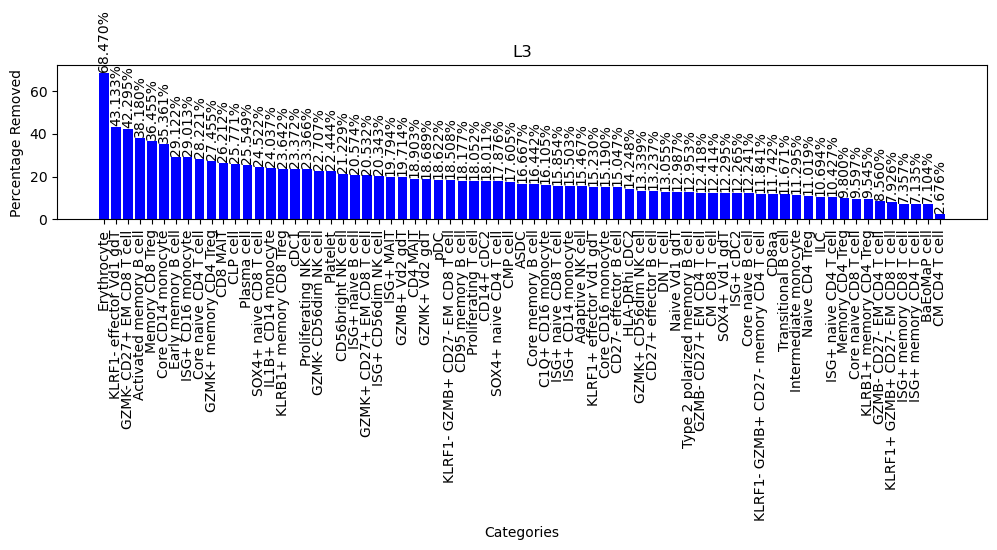

In [ ]:
# Percentage of cells filtered (doublet removal) per L3 cell type
frequency_count_sorted = df.sort_values('percentage_filtered', ascending=False)
frequency_count_sorted.index = frequency_count_sorted['tidy.aifi_l3']
frequency_count_sorted = frequency_count_sorted['percentage_filtered']

plt.figure(figsize=(12, 2))
bars = plt.bar(
    list(frequency_count_sorted.keys()),
    list(frequency_count_sorted.values),
    color='blue'
)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 0.5,
        f"{yval:.3f}%",
        ha='center',
        va='bottom',
        rotation='vertical'
    )

# Axis labels and title
plt.xlabel('Categories')
plt.ylabel('Percentage Removed')
plt.title('L3 - Percentage of Cells Removed by Doublet Filtering')
plt.xticks(rotation='vertical')
plt.show()



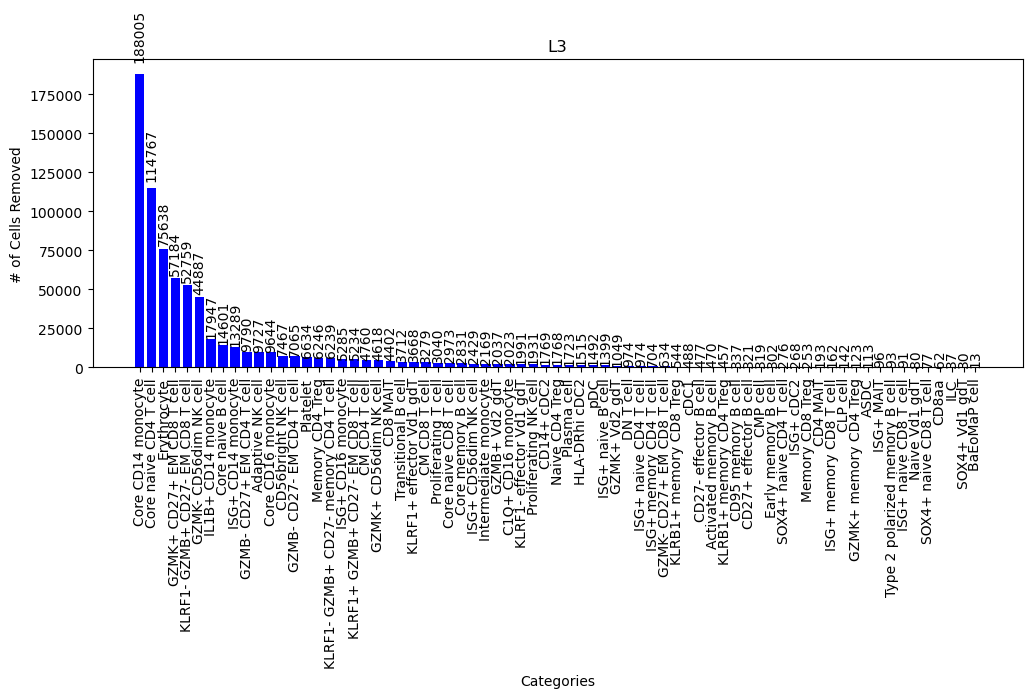

In [ ]:
# Absolute number of cells removed per L3 cell type
frequency_count_sorted = df.sort_values('number_filtered', ascending=False)
frequency_count_sorted.index = frequency_count_sorted['tidy.aifi_l3']
frequency_count_sorted = frequency_count_sorted['number_filtered']

plt.figure(figsize=(12, 4))
bars = plt.bar(
    list(frequency_count_sorted.keys()),
    list(frequency_count_sorted.values),
    color='blue'
)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval * 1.04,
        int(yval),
        ha='center',
        va='bottom',
        rotation='vertical'
    )

# Axis labels and title
plt.xlabel('Categories')
plt.ylabel('# of Cells Removed')
plt.title('L3 - Absolute Number of Cells Removed by Doublet Filtering')
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
# Summary table of all doublet removal statistics
df

,tidy.aifi_l3,count_before,count_after,number_filtered,percentage_filtered
0,ASDC,678,565,113,16.666667
1,Activated memory B cell,1231,761,470,38.180341
2,Adaptive NK cell,62887,53160,9727,15.467426
3,BaEoMaP cell,183,170,13,7.103825
4,C1Q+ CD16 monocyte,12561,10538,2023,16.105406
...,...,...,...,...,...
66,SOX4+ naive CD8 T cell,314,237,77,24.522293
67,Transitional B cell,31804,28092,3712,11.671488
68,Type 2 polarized memory B cell,718,625,93,12.952646
69,cDC1,2088,1600,488,23.371648


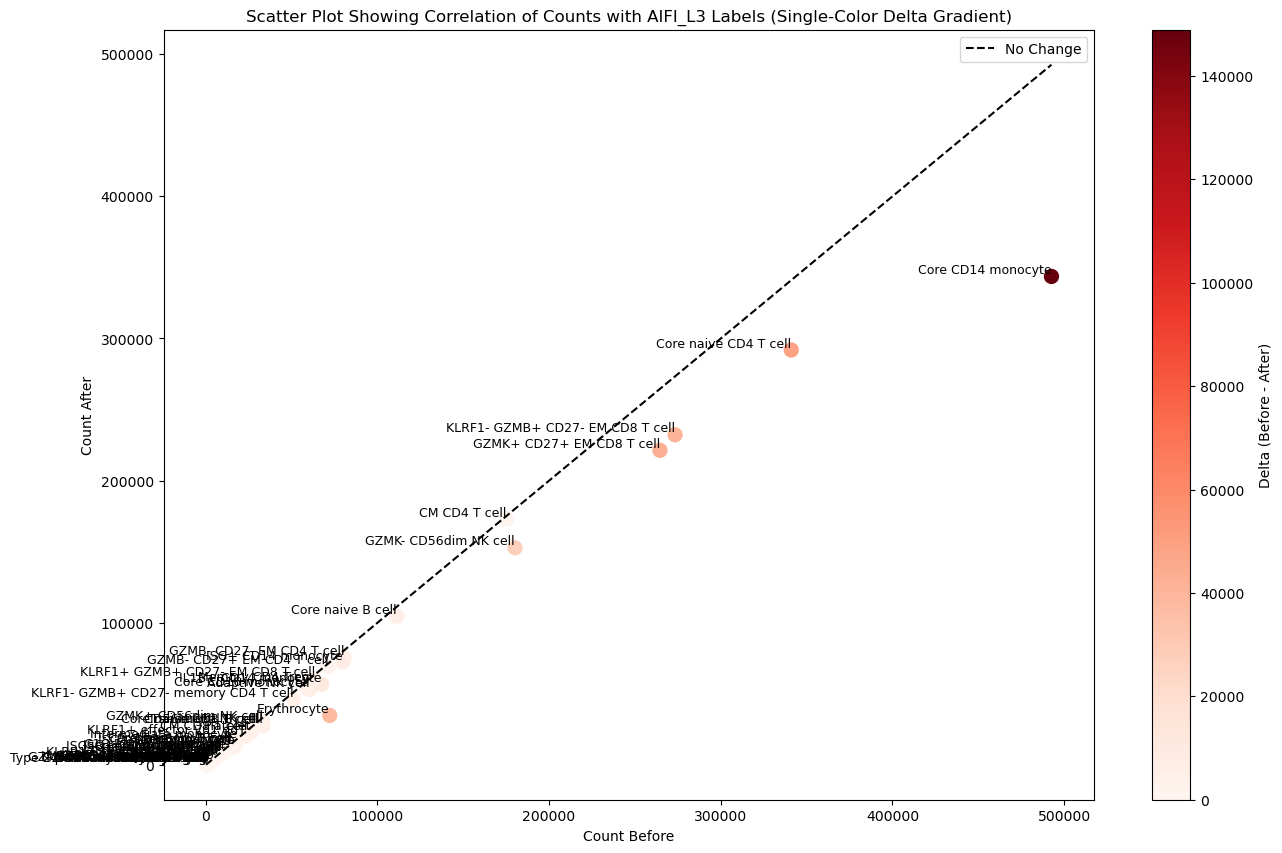

In [ ]:
# Scatter: counts before vs. after doublet removal, colored by delta
df['delta'] = df['count_before'] - df['count_after']

fig, ax = plt.subplots(figsize=(15, 10))
scatter = ax.scatter(df['count_before'], df['count_after'], c=df['delta'], cmap='Reds', s=100)

# Reference line (y = x, i.e. no change)
ax.plot([df['count_before'].min(), df['count_before'].max()],
        [df['count_before'].min(), df['count_before'].max()], 'k--', label="No Change")

# Label each point with cell type
for i, row in df.iterrows():
    ax.text(row['count_before'], row['count_after'], row['tidy.aifi_l3'],
            fontsize=9, ha='right', va='bottom')

plt.colorbar(scatter, ax=ax, label='Delta (Before − After)')
ax.set_xlabel("Count Before")
ax.set_ylabel("Count After")
ax.set_title("Before vs. After Doublet Removal (L3 Cell Types)")
plt.legend()
plt.show()

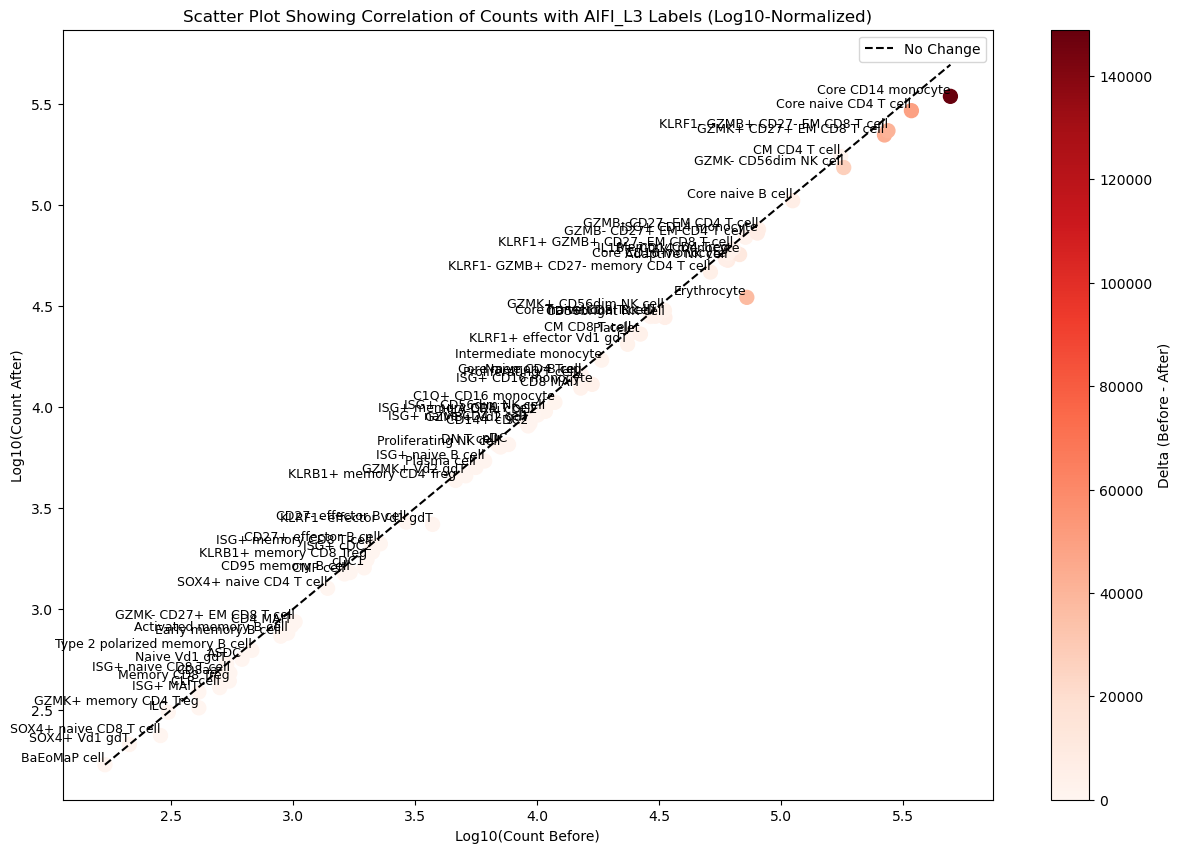

In [ ]:
# Same scatter on log10 scale — reveals low-abundance cell types more clearly
df['log_count_before'] = np.log10(df['count_before'].replace(0, np.nan))
df['log_count_after'] = np.log10(df['count_after'].replace(0, np.nan))

fig, ax = plt.subplots(figsize=(15, 10))
scatter = ax.scatter(
    df['log_count_before'], df['log_count_after'],
    c=df['delta'], cmap='Reds', s=100
)

# Reference line (y = x)
min_val = min(df['log_count_before'].min(), df['log_count_after'].min())
max_val = max(df['log_count_before'].max(), df['log_count_after'].max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', label="No Change")

for i, row in df.iterrows():
    ax.text(row['log_count_before'], row['log_count_after'], row['tidy.aifi_l3'],
            fontsize=9, ha='right', va='bottom')

plt.colorbar(scatter, ax=ax, label='Delta (Before − After)')
ax.set_xlabel("Log10(Count Before)")
ax.set_ylabel("Log10(Count After)")
ax.set_title("Before vs. After Doublet Removal — Log10 Scale (L3)")
plt.legend()
plt.show()